In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_trans = pd.read_csv(r"C:\Users\Zenil\Desktop\Ghost In the Machine\IEEE Dataset\train_transaction.csv")

## 🟦 1. train_transaction → WHAT happened

* 💰 TransactionAmt → how much transaction was involved.?
  
* 🕒 TransactionDT → when did fraud happened (relative time).?

* 💳 card1–card6 → payment details

* 📦 ProductCD → product type

* 🎯 isFraud → target (0 / 1)

* 🧠 V1–V339 → anonymized behavioral features

### 🟨 2. train_identity → WHO is behind it

* 📱 DeviceType → mobile / desktop.

* 💻 DeviceInfo → chrome, samsung, etc

* 🌐 id_31 → browser

* 📏 id_33 → screen resolution

* 🔐 id_12–id_38 → identity / verification signals

In [3]:
df_id = pd.read_csv(r"C:\Users\Zenil\Desktop\Ghost In the Machine\IEEE Dataset\train_identity.csv")

In [4]:
df_id

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


### “Not all transactions have identity data, which itself can act as a signal for fraud.”

In [5]:
df = df_trans.merge(df_id, on="TransactionID", how="left")
df['DeviceType'].isnull().mean()

np.float64(0.7615572188166763)

In [6]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### “The transaction table captures behavioral signals, while the identity table provides contextual signals. Combining both allows detection of inconsistencies, which is critical for fraud detection.”

In [7]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [8]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [9]:
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100 ##normalize=True gives you the relative frequency of each count
## it divides each count by total number of rows. 

for label, pct in fraud_percentage.items():
    print(f"{label}: {pct:.2f}%")

0: 96.50%
1: 3.50%


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

In [11]:
missing

id_24            585793
id_25            585408
id_07            585385
id_08            585385
id_21            585381
                  ...  
C11                   0
C14                   0
C13                   0
C12                   0
TransactionID         0
Length: 434, dtype: int64

### Our Documentation hinted that missing pattern was important in itself missing pattern can act as a signal in itself

### Time Delta Column TransactionDT

What is TransactionDT (time delta)?
- TransactionDT is not a human-readable timestamp (like "2017-12-01 08:30:00").
- Instead, it’s a time delta: the number of seconds elapsed since a fixed reference point (often the start of data collection).
- Example: 86400 means 86,400 seconds after the dataset’s "day zero," which is exactly 1 day later.


In [12]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 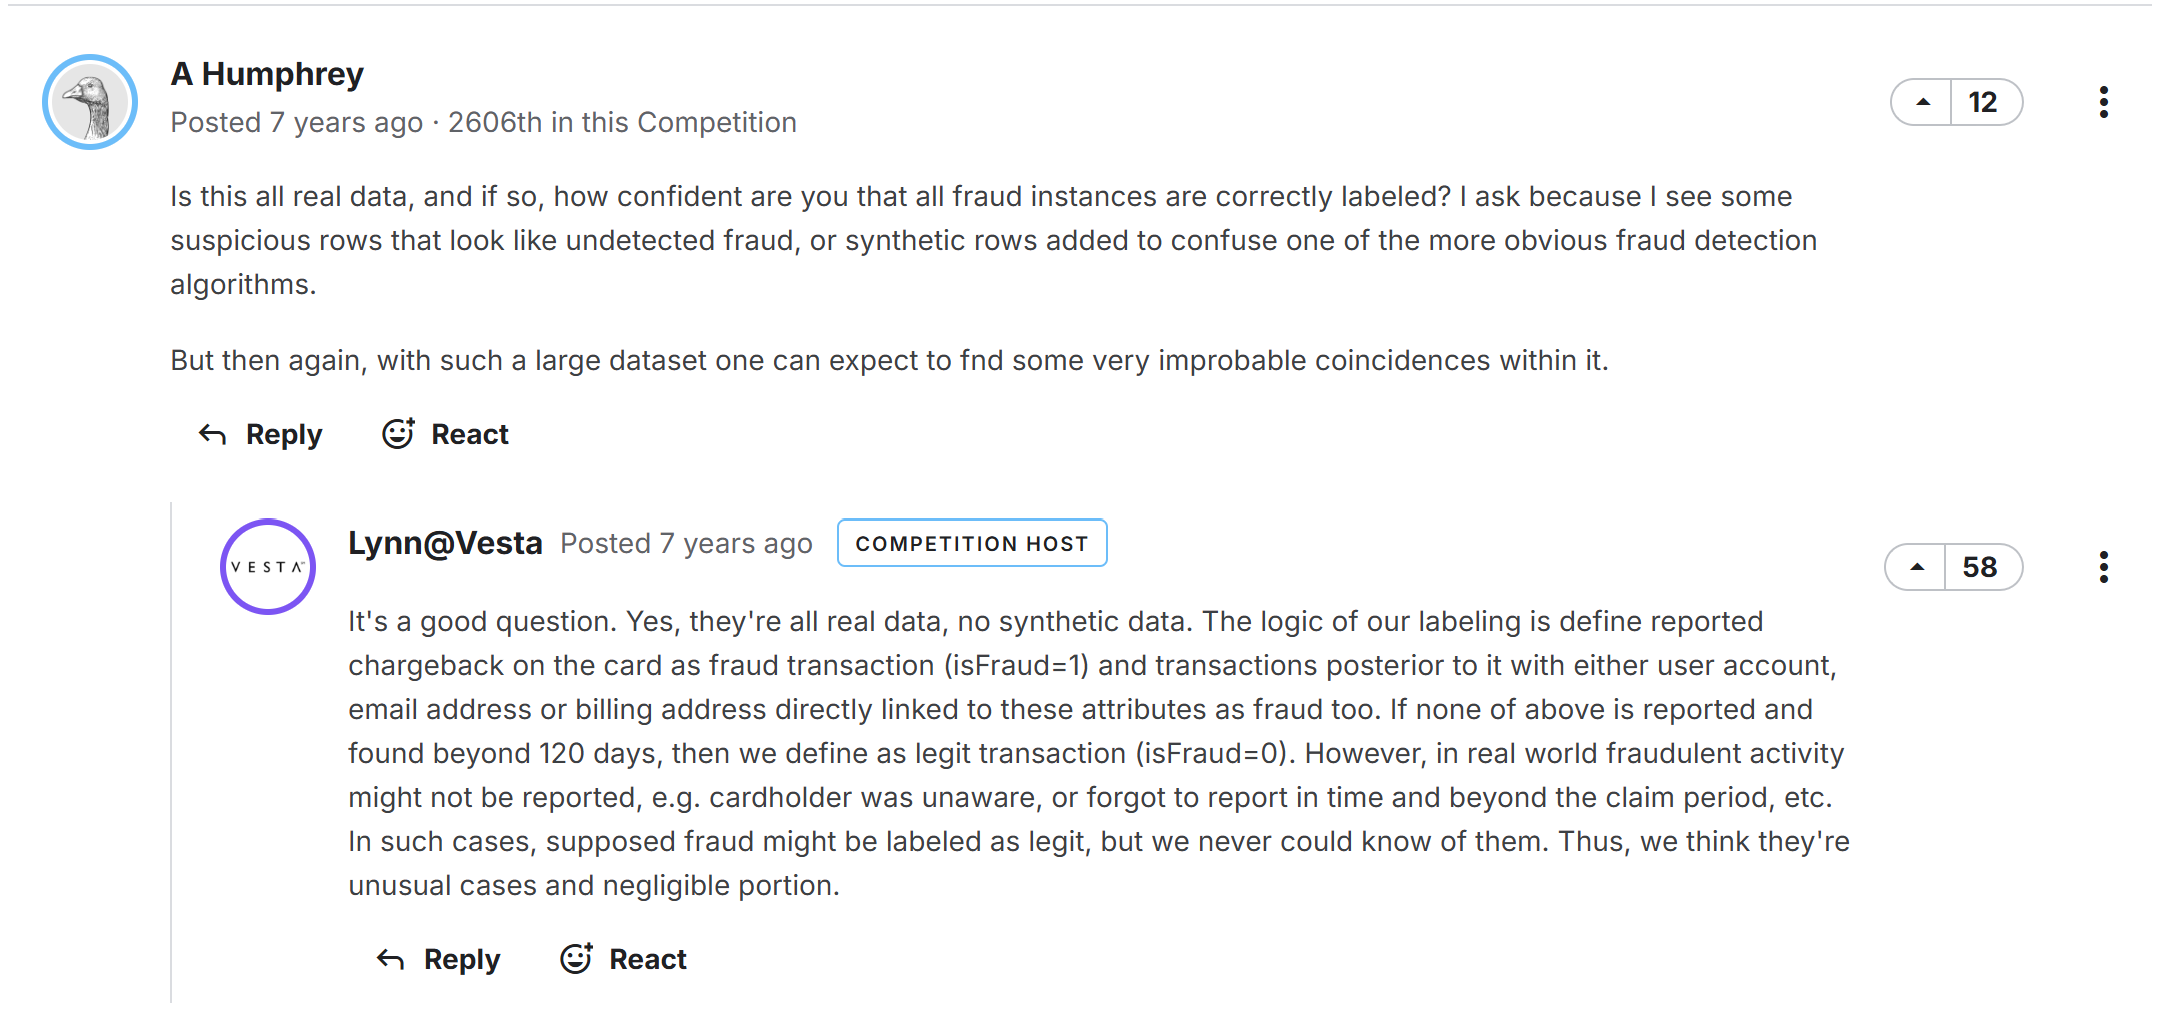

### Golden Insights From Analyzing Kaggle Discussions

* 👉 Fraud ≠ transaction level problem
* 👉 Fraud = USER BEHAVIOR problem

We identified transactions belonging to same user

✅ “decode existing engineered features”

* Rather than Predicting Fraud,We are targetting on human behaviour understanding through data

In [13]:
df.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


### 🧠 OBSERVATIONS 

*  🟦 Non-Fraud (0)
   1. Mean ≈ 134
   2. Median (50%) = 68.5
   3. Max = ~31937 (high outliers)

  
      
*  🟥 Fraud (1)
   1. Mean ≈ 149
   2. Median = 75
   3. Max = ~5191

### Maximum amount by a Fraudster is 5191
### Maximum amount by a Non Fraudster is 31937 (high outliers)

Hence we can infer that fraudsters usually avoid extreme high transactions. 

### . Outliers are mostly legit and hence

👉 High transactions = mostly non-fraud

👉 Fraudsters are operating in a safe zone

Fraudsters mimic normal transaction amounts to avoid detection, which makes TransactionAmt alone a weak predictor.”

In [14]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df['hour'] = ((df['TransactionDT'] / 3600) % 24).astype(int)

In [17]:
df.groupby("hour")["isFraud"].mean()

hour
0     0.031380
1     0.031314
2     0.037483
3     0.038314
4     0.051890
5     0.070302
6     0.077743
7     0.106102
8     0.093014
9     0.089956
10    0.053212
11    0.038816
12    0.030439
13    0.022889
14    0.024216
15    0.025399
16    0.029511
17    0.031530
18    0.035231
19    0.034738
20    0.034273
21    0.034005
22    0.032694
23    0.036997
Name: isFraud, dtype: float64

### Key Insights

1. Morning spike (5 AM – 9 AM)

👉 Fraud peaks.

💥 Especially 7 AM = highest

2. Afternoon dip (1 PM – 4 PM)

👉 Fraud is lowest.

3. Evening / night moderate

👉 Stable fraud rate (~3–4%)

Fraudsters operate in early hours when monitoring is low

# Insight 2:

Normal users peak activity ≠ fraud peak

👉 mismatch = signal

# Insight 3:

Fraud is time-dependent behaviour.

In [18]:
df['hour_fraud_rate'] = df['hour'].map(df.groupby('hour')['isFraud'].mean())

C:\Users\Zenil\AppData\Local\Temp\ipykernel_9068\1923343755.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour_fraud_rate'] = df['hour'].map(df.groupby('hour')['isFraud'].mean())


### We have assigned a Fraud Probability to every hour. 

7 AM → 0.106  
13 PM → 0.022

In [19]:
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,hour_fraud_rate
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.031380
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.031380
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.031380
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.031380
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0,0.031380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,0.036997
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,0.036997
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,0.036997
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,0.036997


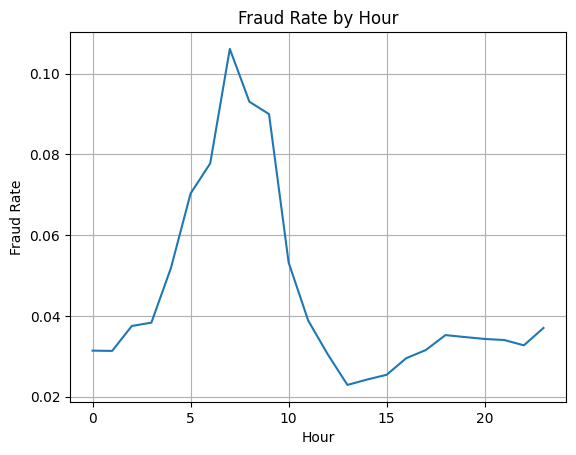

In [22]:
fraud_by_hour = df.groupby("hour")["isFraud"].mean()

fraud_by_hour.plot(kind='line')
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.grid()
plt.show()

### | Value | Meaning          

| 0     | 12:00 AM – 1:00 AM (midnight) 🌙 |
| 5     | 5:00 AM – 6:00 AM                |
| 10    | 10:00 AM – 11:00 AM ☀️           |
| 15    | 3:00 PM – 4:00 PM                |
| 20    | 8:00 PM – 9:00 PM 🌆             |

The hour feature represents a cyclical time pattern derived from TransactionDT, capturing relative daily behavior rather than actual clock time.

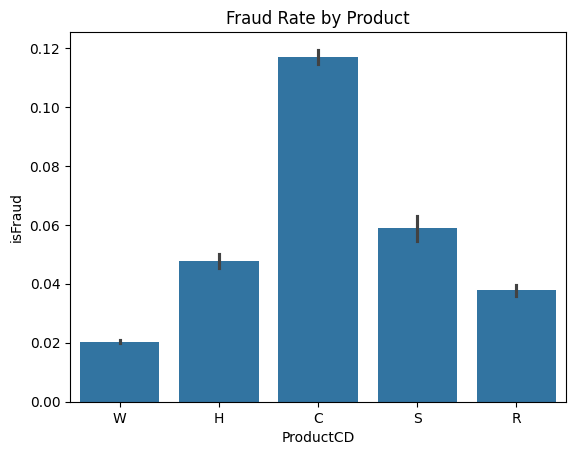

In [25]:
sns.barplot(x='ProductCD', y='isFraud', data=df)
plt.title("Fraud Rate by Product")
plt.show()

### From the chart, here are the key inferences:
- Product C is the riskiest: It shows the highest fraud rate (around 12%), which is significantly above the others. This suggests that transactions involving Product C need stricter monitoring or additional fraud-prevention measures.
  
- Moderate risk products (S, H, R): Fraud rates for S (~6%), H (~5%), and R (~4%) are mid-range. These categories are not as risky as C but still contribute meaningfully to fraud cases.

  
- Product W is the safest: With the lowest fraud rate (~2%), W appears relatively secure compared to the others. It may require less intensive fraud detection resources.

  
- Relative differences matter: The gap between C and W is about 6x, which highlights how fraud risk is not evenly distributed across product categories. This insight can guide resource allocation — focusing more on high-risk categories like C and S.

  
- Error bars indicate uncertainty: While the chart shows clear differences, the small error bars suggest the estimates are fairly reliable, meaning the observed differences are statistically meaningful.


### Fraud Rate by Card Type

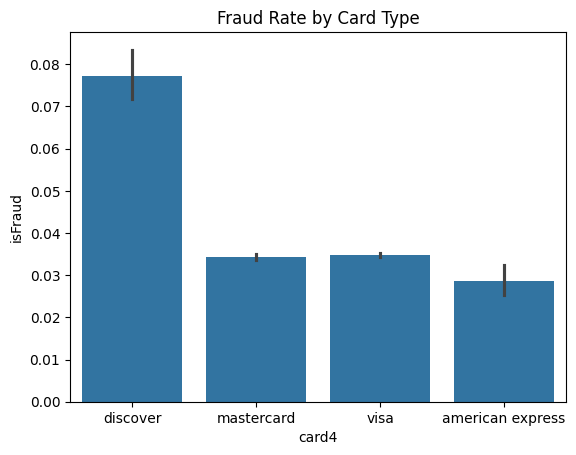

In [26]:
top_cards = df['card4'].value_counts().index

sns.barplot(x='card4', y='isFraud', data=df[df['card4'].isin(top_cards)])
plt.title("Fraud Rate by Card Type")
plt.show()

### 
- Discover cards are most vulnerable: The fraud rate is around 7.5–8%, which is roughly double that of the other card types. This suggests Discover transactions are disproportionately targeted or exposed to fraud.
  
- Other card types (Mastercard, Visa, Amex) are relatively safer: Their fraud rates cluster between 3–4%. While not negligible, they are significantly lower than Discover, indicating stronger fraud resilience or different usage patterns.

  
- Clear disparity across card brands: The difference between Discover (~0.08) and Visa (~0.03) is more than 2x, showing that fraud risk is not evenly distributed across card networks.

  
- Error bars are small: This means the estimates are fairly stable and the differences are statistically meaningful, not just random noise.

Transactions involving Discover may require stricter thresholds, additional verification, or higher model risk scores compared to Visa/Mastercard/Amex.


### Missing vs Fraud (🔥 UNIQUE)

C:\Users\Zenil\AppData\Local\Temp\ipykernel_9068\4045109655.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['missing_count'] = df.isnull().sum(axis=1)


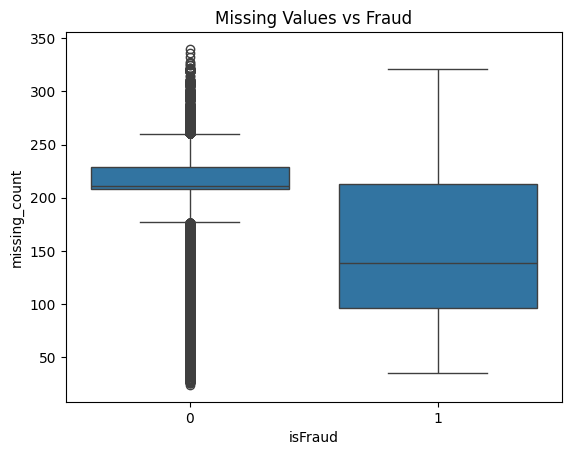

In [27]:
df['missing_count'] = df.isnull().sum(axis=1)

sns.boxplot(x='isFraud', y='missing_count', data=df)
plt.title("Missing Values vs Fraud")
plt.show()

### INTERPRETATION (DEEP)

1. Fraudsters are often providing MORE information to appear legitimate.
   * As from above plot we can see fraud has actually more complete data.

2. Legit users may skip optional fields → more missing.

3. Identity-rich transactions ≠ safe

In [30]:
df['missing_count'] = df.isnull().sum(axis=1)
df['missing_ratio'] = df.isnull().mean(axis=1)

C:\Users\Zenil\AppData\Local\Temp\ipykernel_9068\2928050701.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['missing_ratio'] = df.isnull().mean(axis=1)


### What are VELOCITY FEATURES?

👉 Simple definition:

“How much Activity a User is Doing.?”

⚡ REAL LIFE EXAMPLE
👤 Normal User:
1–2 transactions per day
same device
normal pattern

👻 Fraudster:
5 transactions in 10 minutes 💀
multiple cards / devices
burst activity

👉 These are “speed / frequency” features:

💥 VELOCITY = SPEED OF ACTION

In [37]:
df[['V95','V96','V97']].describe()

,V95,V96,V97
count,590226.000000,590226.00000,590226.000000
mean,1.038019,3.00519,1.718933
std,21.034304,40.23949,27.700449
min,0.000000,0.00000,0.000000
25%,0.000000,0.00000,0.000000
50%,0.000000,0.00000,0.000000
75%,0.000000,1.00000,0.000000
max,880.000000,1410.00000,976.000000


### Top Kaggle Solution Identified

1. V95, V96, V97 → transaction count history
2. V126, V127, V128 → amount history

These features already encode the velocity

In [39]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 6.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
# target
y = df['isFraud']

# drop useless columns
X = df.drop(['isFraud', 'TransactionID'], axis=1)

# sirf numeric columns le (for now)
X = X.select_dtypes(include=['number'])

from lightgbm import LGBMClassifier

model = LGBMClassifier()
model.fit(X, y)

[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38748
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 404
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [43]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.head(20)

card2             165
TransactionAmt    125
card1             115
TransactionDT     111
addr1             100
card5              97
C13                84
C1                 62
D15                59
D2                 58
D1                 52
C14                50
C6                 50
dist1              50
card3              46
C9                 44
C11                44
D4                 43
D10                42
C2                 40
dtype: int32

In [44]:
importances[importances.index.str.startswith('V')].head(10)

V313    29
V83     19
V82     18
V310    18
V45     17
V53     17
V54     16
V296    15
V55     14
V294    14
dtype: int32